# Medical Insurance Cost Analysis
## Spring 2026 Data Science Project

### Names:
- Thirunavukkarasu Sethuraman
- Sasidharan Vaithiyanathan
- Alex Yang

### Contributions

A: Project idea - The entire group as a whole (Thirunavukkarasu Sethuraman, Sasidharan Vaithiyanathan, and Alex Yang) selected this project idea.

B: Dataset Curation and Preprocessing - 

C: Data Exploration and Summary Statistics - Thirunavukkarasu Sethuraman selected and performed each hypothesis test, created conclusions based off of the results of those test, and created plots to show results.

D: ML Algorithm Design/Development -

E: ML Algorithm Training and Test Data Analysis -

F: Visualization, Result Analysis, Conclusion -

G: Final Tutorial Report Creation - The entire group worked on creating the final tutorial report.


# 2. Introduction

Healthcare costs in the United States can vary dramatically depending on a variety of personal and lifestyle factors. Insurance companies often use information such as age, smoking habits, body mass index (BMI), number of children, and geographic region to estimate risk and determine insurance premiums. Understanding which variables have the strongest effect on insurance charges is important because it can help individuals better understand healthcare pricing and identify behaviors that may increase medical expenses.

In this project, we analyze a medical insurance dataset to answer the following questions:

1. How does an individual's insurance charges change based on the various traits of the individual?
2. Does the demographic and health characterisitics of an individual have an effect on the individual's smoking status?
3. Is it possible to categorize individuals into different insurance charge groups (low, medium, high) based on their characteristics?

To answer these questions, we use a combination of statistical hypothesis testing, exploratory data analysis, and machine learning regression models. Through these analyses, we aim to better understand the relationship between personal health characteristics and medical insurance pricing.

# 3. Data Curation

### Imports

The dataset used in this project is the “Medical Cost Personal Dataset” from Kaggle.

#### Citation
Abdel-Ghany, M. (2025). Medical Insurance Cost Dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset

We begin by loading the dataset using pandas and inspecting the first few rows to understand its structure.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [34]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains the following columns:
- age: age of the individual
- sex: gender
- bmi: body mass index
- children: number of dependents
- smoker: smoking status (yes/no)
- region: residential region
- charges: medical insurance cost

### Initial Data Inspection

Before performing any analysis, we check for missing values and verify that all data types are appropriate.

In [35]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

The dataset contains no missing values, meaning no imputation or row removal is required. This ensures that all observations can be used directly in analysis and modeling.

We can also check if there are any duplicate entries within the dataframe. If so, we can clean up the table by removing those entries.

In [36]:
print(f'Number of Duplicate Entries: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Number of Duplicate Entries (After Cleaning): {df.duplicated().sum()}')

Number of Duplicate Entries: 1
Number of Duplicate Entries (After Cleaning): 0


### Basic Data Characteristics

We next examine summary statistics to understand the distribution of numerical variables such as age, BMI, and insurance charges.

In [37]:
print(f'Dimension of the Table: {df.shape}\n') ## row by columns
print(f'Features: {df.columns}\n') ## names of columns/features
print(f'Feature Types: {df.dtypes}\n') ## datatypes of the features
print(f'Summary of Statistics of the Dataset: {df.describe()}\n') ## summary statistics

Dimension of the Table: (1337, 7)

Features: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Feature Types: age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Summary of Statistics of the Dataset:                age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010



# 4. Exploratory Data Analysis (EDA)

### Data Exploration: Part 1

For the first hypothesis test, we decided to test whether or not insurance charges varied significantly across different geographic regions. In order to identify the relationship between the two variables we decided to choose an ANOVA test since we were comparing the mean insurance charges across 3+ groups. Each group was a particular region: northwest, northeast, southwest, southeast.

Here the null hypothesis is that there is no statistical difference in mean insurance charges between the regions, and the alternative hypothesis is that there is a statistical difference in mean insurance charges between at least one pair of regions.

1) Hypothesis Testing: ANOVA test (3+ groups) (Region vs. Insurance Charges)

In [38]:
nw = df[df["region"] == "northwest"]["charges"]
ne = df[df["region"] == "northeast"]["charges"]
sw = df[df["region"] == "southwest"]["charges"]
se = df[df["region"] == "southeast"]["charges"]

f_statistic, p_value = stats.f_oneway(nw, ne, sw, se) ## ANOVA test
print(f'f_statistic: {f_statistic}, p_value: {p_value}')

f_statistic: 2.926139903662777, p_value: 0.03276288025447231


Given the output of the ANOVA test, the returned p-value was approximately 0.03 which is less than 0.05. Thus, we can reject the null hypothesis and conclude that there is a statistically significant difference in insurance charges across regions.

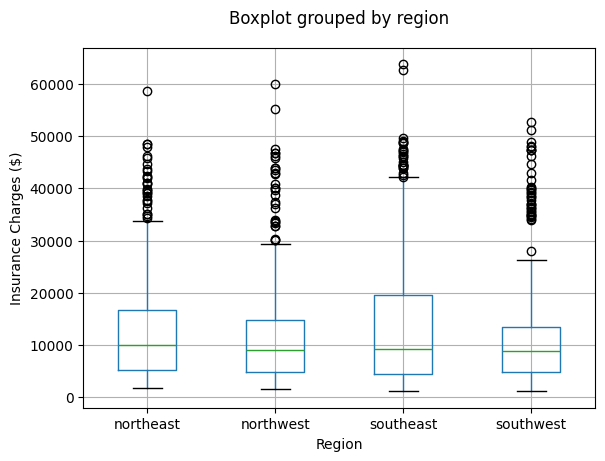

In [39]:
bp = df.boxplot(column="charges", by="region")
bp.get_figure().gca().set_title("")

plt.xlabel("Region")
plt.ylabel("Insurance Charges ($)")

plt.show()

We then decided to represent this data in a boxplot since it is great at highlighting the distribution of insurance charges across the different geographical regions. Now, while the p-value indicates that there is a statistically significant difference between the two variables, the boxplot distributions considerably overlap one another. The boxplot corresponding to the southeast region displays a high spread of data (variability), demonstrating that this region contributes heavily to the statistical significance. However, since there is high overlap amongst the boxplots, it is likely there are other factors that significantly affect insurance charges.

### Data Exploration 2

For the second hypothesis test, we decided to analyze whether or not there was a statistical relationship between whether or not an individual was a smoker and their corresponding BMI. A Chi-Square test was chosen to examine the association between two categorical variables since we wanted to determine the relationship between the two and see if the final results are as expected or not.

The null hypothesis is that there is no statistical difference between BMI and the smoking status of an individual, and the alternative hypothesis is that there is a statistical difference between BMI and the smoking status of an individual.

2. Chi-Square Test (Smoker Status vs. BMI)

In [40]:
# Contingency Table between smoker and bmi fields
df['bmi_groups'] = pd.cut(df['bmi'], bins=[15, 20, 25, 30, 35, 40, 45, 50, 55], labels=["15-20", "20-25", "25-30", "30-35", "35-40", "40-45", "45-50", "50-55"])
contingency_table = pd.crosstab(df['bmi_groups'], df['smoker'])
contingency_table

smoker,no,yes
bmi_groups,,
15-20,32,9
20-25,160,46
25-30,311,75
30-35,315,73
35-40,175,50
40-45,55,16
45-50,13,4
50-55,2,1


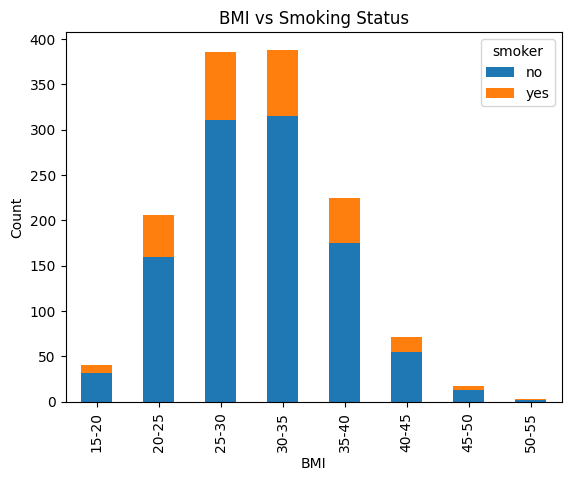

In [41]:
contingency_table.plot(kind='bar', stacked=True)
plt.title("BMI vs Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

In [42]:
_, p, _, _ = stats.chi2_contingency(contingency_table)
print(f'P-Value: {p}')

P-Value: 0.933488860056868


The outputted p-value by the test was approximately 0.93, which is greater than 0.05. Thus, we fail to reject the null hypothesis and conclude that there is no statistical relationship between BMI and smoking status.

### Data Exploration: Part 3

For the final hypothesis test, we decided to analyze whether or not an individual is a smoker had an effect on their insurance charges. We chose to apply a Mann-Whitney U test, which is great for this scenario since we are comparing differences between two independent groups (smokers vs. non-smokers) when the dependent variable (insurance charges) is continuous but not normally distributed. 

Here the null hypothesis is that there is no statistical difference between the smoking status and the insurance charges of an individual, and the alternative hypothesis is that there is a statistical difference between the smoking status and the insurance charges of an individual.

3. Mann-Whitney U Test (Smoker Status vs. Charges)

In [43]:
smoker = df[df['smoker'] == 'yes']['charges']
non_smoker = df[df['smoker'] == 'no']['charges']

_, p = stats.mannwhitneyu(non_smoker, smoker)
print(f'P-Value: {p}')

P-Value: 5.74701188239214e-130


The Mann-Whitney U test returned a p-value of approximately $5.27 \times 10^{-130}$ and $5.27 \times 10^{-130} << 0.05$. Consequently, it is fair to reject the null hypothesis and conclude that there is highly significant statistical difference in insurance charges between those who smoke and those who do not.

We then decided to represent this data in a boxplot since boxplots are able to display the data as a distribution and the overall spread of insurance charges across both groups.

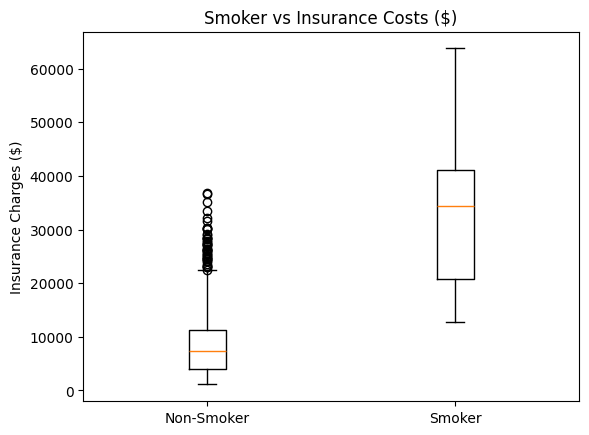

In [51]:
plt.boxplot([non_smoker, smoker], tick_labels=['Non-Smoker', 'Smoker'])
plt.title('Smoker vs Insurance Costs ($)')
plt.ylabel('Insurance Charges ($)')
plt.show()

The boxplots are quite different from one another since the mean insurance charge for an individual who does not smoke is a little less than $10,000, meanwhile the mean insurance cost for a smoker is around $35,000. There also exists a large spread of smokers compared to non-smokers which is indicated by their quartiles (edges) being farther apart than the mean. Therefore, it is fair to say that the binary value of whether or not an individual is a smoker is a strong relationship to use for future predictions.

# 5. Primary Analysis

### Question 1: How does an individual's insurance charges change based on the various traits of the individual?

Let's begin by analyzing the data and how various characteristics have an influence on an individual's insurance costs. The remainder of this section will focus on utilizing a linear regression model to predict an individual's insurance charges.

We can begin by importing the necessary packages.

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Going through the different datatypes of the features we can tell that there are some non-numerical features that need to be addressed/modified before proceeding with the training phase. This is because linear regression cannot handle objects and any object fields must be converted using some form of encoding. For this problem, we decided to perform one-hot encoding on the three categorical variables (sex, smoker, and region).

In [58]:
numerical_df = pd.get_dummies(df.drop(columns=['bmi_groups']), columns=['sex', 'region', 'smoker'])
numerical_df

,age,bmi,children,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,True,False,False,False,False,True,False,True
1,18,33.770,1,1725.55230,False,True,False,False,True,False,True,False
2,28,33.000,3,4449.46200,False,True,False,False,True,False,True,False
3,33,22.705,0,21984.47061,False,True,False,True,False,False,True,False
4,32,28.880,0,3866.85520,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,False,True,False,False,True,False
1334,18,31.920,0,2205.98080,True,False,True,False,False,False,True,False
1335,18,36.850,0,1629.83350,True,False,False,False,True,False,True,False
1336,21,25.800,0,2007.94500,True,False,False,False,False,True,True,False


### Training the Model

In [57]:
X = numerical_df.drop('charges', axis=1)
y = numerical_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'R^2 Score: {r2}')

ValueError: Cannot cast str dtype to float64

A Mean Squared Error (MSE) is roughly 35,478,020 and taking the square root of this value will give is the average deviation from the mean is $5,956. The $R^2$ value is roughly 0.81 which means the model explains about %81 percent of the variance in insurance changes. This is a good fit since the value is quite close to 1.

We were curious on which features contributed the most to the overall insurance cost, so we obtained the feature coefficients which are basically the weights attached to each feature. 

Higher feature coefficient = Higher Importance and Lower feature coefficient = Lower Importance

In [ ]:
feature_coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(feature_coef.sort_values('Coefficient', ascending=False))

             Feature   Coefficient
10        smoker_yes  11538.882296
2           children    533.009989
5   region_northeast    472.455206
1                bmi    318.701441
0                age    248.210720
6   region_northwest     80.693751
3         sex_female     50.771027
4           sex_male    -50.771027
8   region_southwest   -186.684546
7   region_southeast   -366.464410
9          smoker_no -11538.882296


This shows that if an individual is a smoker, number of children they have, and the northeast region have the strongest weights. Hence, the largest impact on insurance charges.

# 6. Visualization

Now that we have trained the model and computed our metrics, we want to visualize the results to better understand how the model is performing. We'll create three plots: a predicted vs actual scatter to see how close the predictions are to the true values, a residual plot to check whether the model's errors follow any pattern, and a bar chart of feature coefficients to see which traits have the strongest effect on insurance charges.

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# y=x reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction (y = x)')

plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Predicted vs Actual Insurance Charges')
plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x600 with 0 Axes>